In [10]:
"""
Baseline Modeling Pipeline — WV Opioid Data
Target: CHANGE in LA_Tot_Opioid_Clms (next year minus current year)

Features: raw socioeconomic + YoY deltas for all features + poverty x rucc
Models:   Ridge, ElasticNet, Random Forest, Gradient Boosting, XGBoost
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils import resample
from xgboost import XGBRegressor

In [11]:
# ── 1. Load & sort ─────────────────────────────────────────────
df = pd.read_csv("../data/west_virginia_opioid_data_clean.csv")
df = df.sort_values(['FIPS_Code', 'Year']).reset_index(drop=True)

In [12]:
# ── 2. Target (LEVEL, not change) ──────────────────────────────
df['target'] = df.groupby('FIPS_Code')['LA_Tot_Opioid_Clms'].shift(-1)

In [13]:
# ── 3. Lag features (CRITICAL) ─────────────────────────────────
df['claims_lag1'] = df.groupby('FIPS_Code')['LA_Tot_Opioid_Clms'].shift(1)
df['claims_lag2'] = df.groupby('FIPS_Code')['LA_Tot_Opioid_Clms'].shift(2)
# Rolling stats (only using past data → no leakage)
df['rolling_mean_3'] = (
    df.groupby('FIPS_Code')['LA_Tot_Opioid_Clms']
    .shift(1).rolling(3).mean()
)
df['rolling_std_3'] = (
    df.groupby('FIPS_Code')['LA_Tot_Opioid_Clms']
    .shift(1).rolling(3).std()
)
# Trend (approx slope)
df['trend_3'] = (
    df.groupby('FIPS_Code')['LA_Tot_Opioid_Clms']
    .shift(1).diff().rolling(3).mean()
)

In [14]:
# ── 4. Keep your socioecon features ────────────────────────────
base_features = [
    'Labor_Force_Participation_Rate',
    'Unemployment_Rate',
    'Median_Household_Income',
    'Poverty_Percent_All_Ages',
    'Pct_Bachelors_Plus',
    'Rural_Urban_Continuum_Code'
]
time_features = [
    'claims_lag1',
    'claims_lag2',
    'rolling_mean_3',
    'rolling_std_3',
    'trend_3'
]
feature_cols = base_features + time_features

In [15]:
# ── 5. Drop NA rows safely ─────────────────────────────────────
df_model = df.dropna(subset=feature_cols + ['target']).reset_index(drop=True)

In [16]:
# ── 6. Model (focus on XGBoost) ────────────────────────────────
model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42
)

In [17]:
# ── 7. LOYO CV (clean) ─────────────────────────────────────────
years = sorted(df_model['Year'].unique())
results = []

for test_year in years[-3:]:
    train = df_model[df_model['Year'] < test_year]
    test  = df_model[df_model['Year'] == test_year]

    X_train, y_train = train[feature_cols], train['target']
    X_test, y_test   = test[feature_cols], test['target']

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        'year': test_year,
        'r2': r2_score(y_test, preds),
        'rmse': root_mean_squared_error(y_test, preds),
        'mae': mean_absolute_error(y_test, preds)
    })

print(pd.DataFrame(results))

   year        r2        rmse         mae
0  2020  0.905754  359.933802  135.894380
1  2021  0.818167  458.623058  163.381192
2  2022  0.843329  303.526077  108.879237


C:\Users\sakthink\AppData\Local\Temp\ipykernel_7656\2237965559.py:178: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight",


Saved.


c:\Users\sakthink\Learning\Code\ITCS_6100\The-Intervention-Task-Force\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


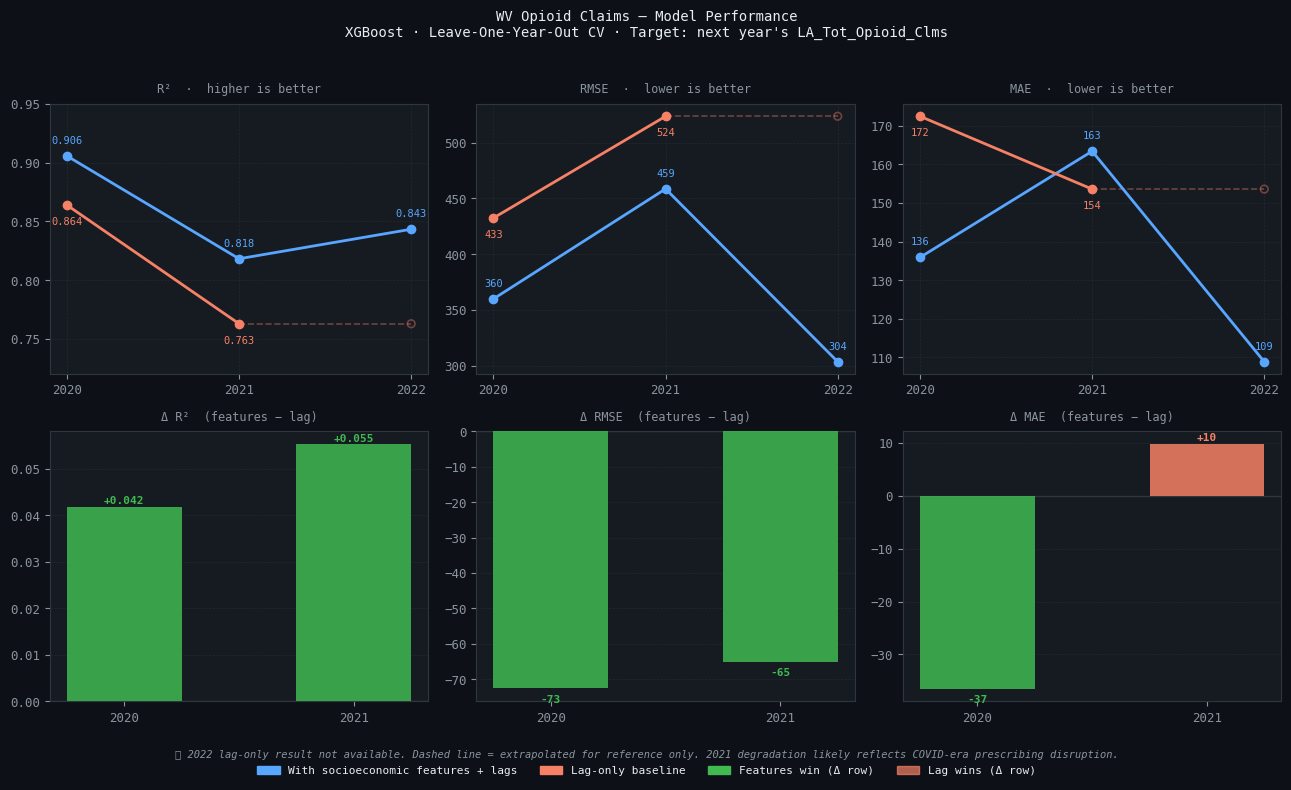

In [18]:
"""
Model Comparison Chart — WV Opioid Data
With features vs Lag-only baseline
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── DATA ──────────────────────────────────────────────────────
years = [2020, 2021, 2022]

with_feat = {
    "r2":   [0.905754, 0.818167, 0.843329],
    "rmse": [359.933,  458.623,  303.526],
    "mae":  [135.894,  163.381,  108.879],
}

lag_only = {
    "r2":   [0.863895, 0.762832, None],
    "rmse": [432.541,  523.778,  None],
    "mae":  [172.421,  153.563,  None],
}

# ── STYLE ─────────────────────────────────────────────────────
BLUE    = "#58a6ff"
RED     = "#f78166"
GREEN   = "#3fb950"
YELLOW  = "#d29922"
BG      = "#0d1117"
SURFACE = "#161b22"
BORDER  = "#30363d"
MUTED   = "#8b949e"
TEXT    = "#e6edf3"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    SURFACE,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   MUTED,
    "axes.titlecolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "grid.color":        BORDER,
    "text.color":        TEXT,
    "font.family":       "monospace",
    "font.size":         9,
})

# FIX: invert=False for RMSE and MAE so lower values sit at the bottom (intuitive)
metrics = [
    ("r2",   "R²",   "higher is better",  False, (0.72, 0.95)),
    ("rmse", "RMSE", "lower is better",   False, None),
    ("mae",  "MAE",  "lower is better",   False, None),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle(
    "WV Opioid Claims — Model Performance\n"
    "XGBoost · Leave-One-Year-Out CV · Target: next year's LA_Tot_Opioid_Clms",
    fontsize=10, color=TEXT, y=0.98
)

# ── TOP ROW: line charts ───────────────────────────────────────
for ax, (key, label, sublabel, invert, ylim) in zip(axes[0], metrics):

    feat_vals = with_feat[key]
    lag_vals  = lag_only[key]

    # solid line for with-features (all 3 years)
    ax.plot(years, feat_vals, color=BLUE, linewidth=2,
            marker="o", markersize=6, label="With features", zorder=3)

    # solid line for lag-only where data exists, dashed gap to 2022
    lag_x     = [y for y, v in zip(years, lag_vals) if v is not None]
    lag_y     = [v for v in lag_vals if v is not None]
    ax.plot(lag_x, lag_y, color=RED, linewidth=2,
            marker="o", markersize=6, label="Lag only", zorder=3)

    # dashed extension to show missing 2022
    if lag_x:
        ax.plot([lag_x[-1], 2022], [lag_y[-1], lag_y[-1]],
                color=RED, linewidth=1.2, linestyle="--", alpha=0.4, zorder=2)
        ax.scatter([2022], [lag_y[-1]], color=RED, s=30,
                   facecolors="none", edgecolors=RED, linewidths=1.2,
                   alpha=0.4, zorder=3)

    ax.set_title(f"{label}  ·  {sublabel}", fontsize=8.5, pad=8, color=MUTED)
    ax.set_xticks(years)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    if ylim:
        ax.set_ylim(*ylim)
    # invert is now False for all — no axis flipping

    # annotate each point
    for x, y_val in zip(years, feat_vals):
        ax.annotate(f"{y_val:.3f}" if key == "r2" else f"{y_val:.0f}",
                    (x, y_val), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=7.5, color=BLUE)

    for x, y_val in zip(lag_x, lag_y):
        ax.annotate(f"{y_val:.3f}" if key == "r2" else f"{y_val:.0f}",
                    (x, y_val), textcoords="offset points",
                    xytext=(0, -14), ha="center", fontsize=7.5, color=RED)

# ── BOTTOM ROW: delta bar charts ──────────────────────────────
deltas = {}
for key in ("r2", "rmse", "mae"):
    deltas[key] = [
        (f - l) if (f is not None and l is not None) else None
        for f, l in zip(with_feat[key], lag_only[key])
    ]

# higher_better: True means positive delta = features win
higher_better = {"r2": True, "rmse": False, "mae": False}

for ax, (key, label, sublabel, _, __) in zip(axes[1], metrics):
    d_vals = deltas[key]
    hb     = higher_better[key]

    bar_colors = []
    bar_vals   = []
    bar_years  = []

    for yr, dv in zip(years, d_vals):
        if dv is None:
            continue
        bar_years.append(yr)
        bar_vals.append(dv)
        # green if features win, red if lag wins
        wins = (dv > 0) if hb else (dv < 0)
        bar_colors.append(GREEN if wins else RED)

    x_pos = np.arange(len(bar_years))
    bars  = ax.bar(x_pos, bar_vals, color=bar_colors,
                   width=0.5, zorder=3, alpha=0.85)

    ax.axhline(0, color=BORDER, linewidth=1, zorder=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(y) for y in bar_years])
    ax.set_title(f"Δ {label}  (features − lag)", fontsize=8.5, pad=8, color=MUTED)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

    for bar, val in zip(bars, bar_vals):
        offset = 2 if val >= 0 else -10
        ax.annotate(
            f"{val:+.3f}" if key == "r2" else f"{val:+.0f}",
            (bar.get_x() + bar.get_width() / 2, val),
            textcoords="offset points",
            xytext=(0, offset), ha="center", fontsize=8,
            color=GREEN if ((val > 0) == hb) else RED,
            fontweight="bold"
        )

# ── LEGEND ────────────────────────────────────────────────────
feat_patch  = mpatches.Patch(color=BLUE,   label="With socioeconomic features + lags")
lag_patch   = mpatches.Patch(color=RED,    label="Lag-only baseline")
win_patch   = mpatches.Patch(color=GREEN,  label="Features win (Δ row)")
lose_patch  = mpatches.Patch(color=RED,    label="Lag wins (Δ row)", alpha=0.7)

fig.legend(
    handles=[feat_patch, lag_patch, win_patch, lose_patch],
    loc="lower center", ncol=4, frameon=False,
    fontsize=8, labelcolor=TEXT,
    bbox_to_anchor=(0.5, 0.01)
)

# footnote
fig.text(
    0.5, 0.045,
    "★ 2022 lag-only result not available. "
    "Dashed line = extrapolated for reference only. "
    "2021 degradation likely reflects COVID-era prescribing disruption.",
    ha="center", fontsize=7.5, color=MUTED, style="italic"
)

plt.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight",
            facecolor=BG)
print("Saved.")


Model R² on 2022: 0.8433

  TOP 10 COUNTIES — OPIOID DISTRESS SCORE  |  Forecast year: 2022
  Rank  County                Score  Urgency     Pred Claims
  ------------------------------------------------------------
  1     Hancock              100.0   CRITICAL              1
  2     Webster               92.2   CRITICAL              0
  3     McDowell              81.6   CRITICAL              0
  4     Calhoun               72.9   HIGH                  0
  5     Mingo                 71.6   HIGH                  0
  6     Cabell                67.9   HIGH                  1
  7     Braxton               64.9   HIGH                  0
  8     Wyoming               62.3   HIGH                  0
  9     Nicholas              48.3   MODERATE              0
  10    Logan                 47.9   MODERATE              0



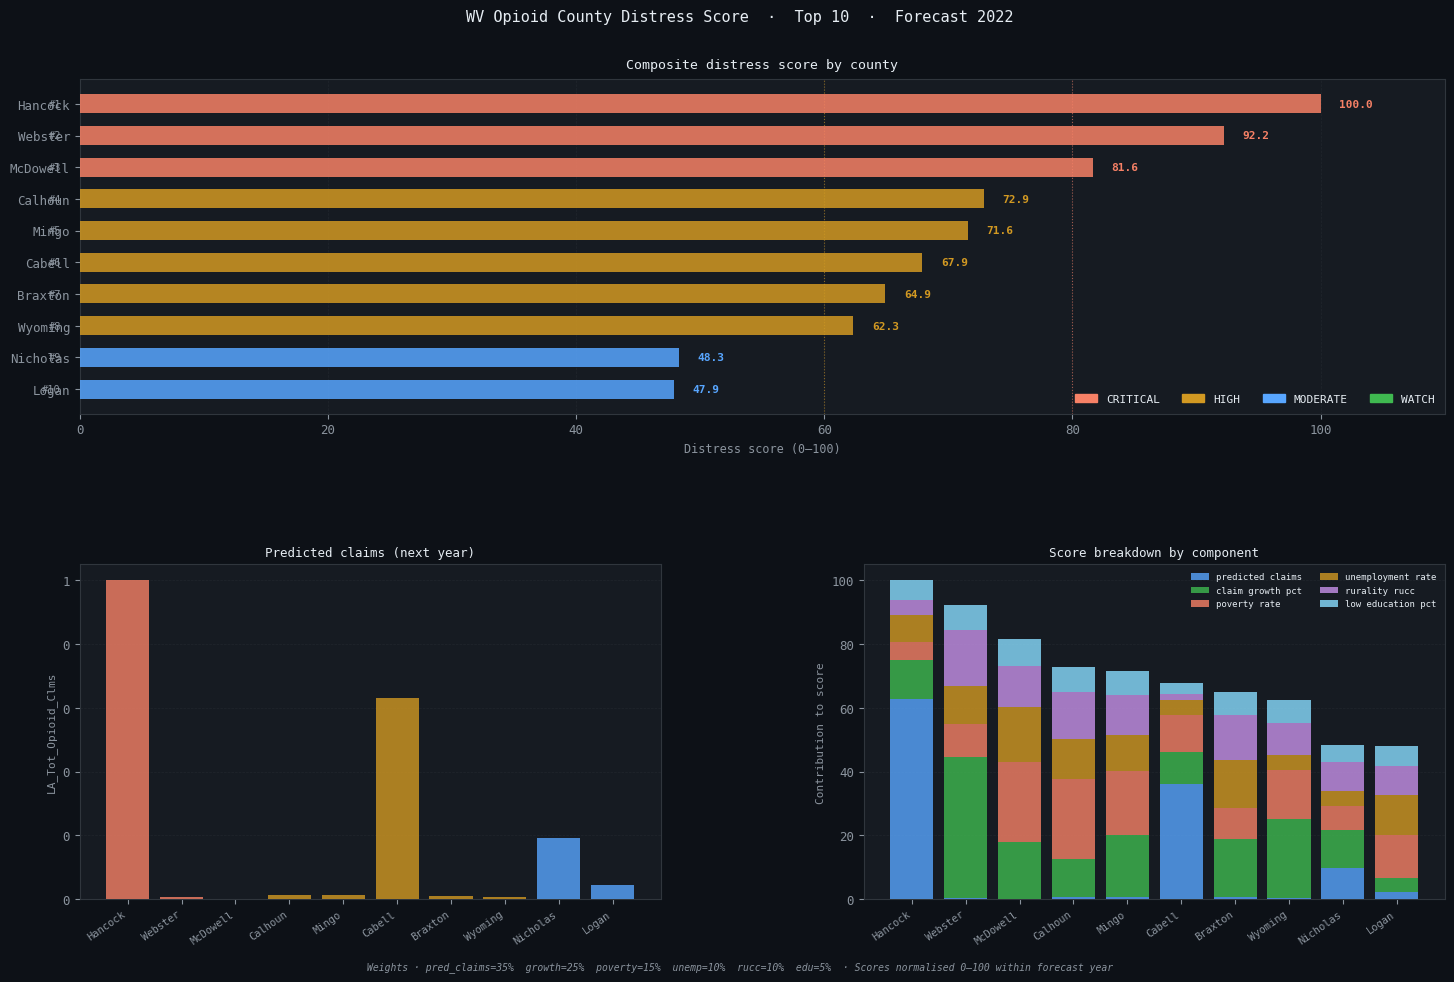

Saved → distress_score_top10.png
Saved → distress_scores_full.csv


In [19]:
"""
County Opioid Distress Score Calculator — WV
============================================
Step 4 of the modeling pipeline.

Loads the clean dataset, runs the trained XGBoost model (LOYO CV),
then builds a weighted composite distress score for every county
and prints / saves the Top-10 counties that need intervention fastest.

Weights (adjustable at the top of the script):
  - Predicted next-year claims   : 35 %
  - YoY claim growth trend       : 25 %
  - Poverty rate                 : 15 %
  - Unemployment rate            : 10 %
  - Rurality (RUCC)              : 10 %
  - Low education (no bachelor's):  5 %
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

# ── 0. USER-TUNABLE WEIGHTS ───────────────────────────────────────────────────
WEIGHTS = {
    "predicted_claims":  0.35,
    "claim_growth_pct":  0.25,
    "poverty_rate":      0.15,
    "unemployment_rate": 0.10,
    "rurality_rucc":     0.10,
    "low_education_pct": 0.05,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-6, "Weights must sum to 1.0"

FORECAST_YEAR = 2022   # year we want to rank counties for
TOP_N         = 10

# ── 1. Load & sort ────────────────────────────────────────────────────────────
df = pd.read_csv("../data/west_virginia_opioid_data_clean.csv")
df = df.sort_values(["FIPS_Code", "Year"]).reset_index(drop=True)

# ── 2. Target: next-year level ────────────────────────────────────────────────
df["target"] = df.groupby("FIPS_Code")["LA_Tot_Opioid_Clms"].shift(-1)

# ── 3. Lag / rolling features (no leakage) ───────────────────────────────────
g = df.groupby("FIPS_Code")["LA_Tot_Opioid_Clms"]

df["claims_lag1"]    = g.shift(1)
df["claims_lag2"]    = g.shift(2)
df["rolling_mean_3"] = g.shift(1).rolling(3).mean()
df["rolling_std_3"]  = g.shift(1).rolling(3).std()
df["trend_3"]        = g.shift(1).diff().rolling(3).mean()

# YoY growth % (used in distress score, not as model input)
df["claims_yoy_pct"] = (
    (df["LA_Tot_Opioid_Clms"] - g.shift(1)) / g.shift(1).replace(0, np.nan) * 100
)

# Low-education proxy: inverse of bachelor's rate
df["low_education_pct"] = 100 - df["Pct_Bachelors_Plus"]

# ── 4. Feature columns ────────────────────────────────────────────────────────
base_features = [
    "Labor_Force_Participation_Rate",
    "Unemployment_Rate",
    "Median_Household_Income",
    "Poverty_Percent_All_Ages",
    "Pct_Bachelors_Plus",
    "Rural_Urban_Continuum_Code",
]
time_features = ["claims_lag1", "claims_lag2", "rolling_mean_3", "rolling_std_3", "trend_3"]
feature_cols  = base_features + time_features

df_model = df.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)

# ── 5. LOYO CV — train on all years < FORECAST_YEAR, predict FORECAST_YEAR ───
train = df_model[df_model["Year"] < FORECAST_YEAR]
test  = df_model[df_model["Year"] == FORECAST_YEAR]

model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    verbosity=0,
)
model.fit(train[feature_cols], train["target"])
test = test.copy()
test["predicted_claims"] = model.predict(test[feature_cols])

print(f"\nModel R² on {FORECAST_YEAR}: {r2_score(test['target'], test['predicted_claims']):.4f}")

# ── 6. Build distress score ───────────────────────────────────────────────────
score_df = test[[
    "FIPS_Code", "Year",
    "Poverty_Percent_All_Ages",
    "Unemployment_Rate",
    "Rural_Urban_Continuum_Code",
    "low_education_pct",
    "claims_yoy_pct",
    "predicted_claims",
]].copy()

# Rename for clarity
score_df = score_df.rename(columns={
    "Poverty_Percent_All_Ages":  "poverty_rate",
    "Unemployment_Rate":         "unemployment_rate",
    "Rural_Urban_Continuum_Code":"rurality_rucc",
    "claims_yoy_pct":            "claim_growth_pct",
})

# Add county name — checks common column name variants in the CSV
NAME_COL_CANDIDATES = ["County_Name", "County", "Area_Name", "county_name", "county"]
name_col = next((c for c in NAME_COL_CANDIDATES if c in df.columns), None)

if name_col:
    name_map = (
        df[["FIPS_Code", name_col]]
        .drop_duplicates()
        .set_index("FIPS_Code")[name_col]
    )
    score_df["county"] = score_df["FIPS_Code"].map(name_map)
else:
    raise ValueError(
        f"No county name column found. Columns in your CSV: {list(df.columns)}\n"
        "Add a 'County_Name' column or rename an existing one."
    )

# Fill any NaN growth with 0 (first-year counties)
score_df["claim_growth_pct"] = score_df["claim_growth_pct"].fillna(0)

# Min-max normalise each component to [0, 1]
components = list(WEIGHTS.keys())
scaler = MinMaxScaler()
score_df[components] = scaler.fit_transform(score_df[components])

# Weighted sum
score_df["distress_score"] = sum(
    score_df[col] * w for col, w in WEIGHTS.items()
)

# Scale to 0–100 for readability
score_df["distress_score"] = (
    (score_df["distress_score"] - score_df["distress_score"].min()) /
    (score_df["distress_score"].max() - score_df["distress_score"].min()) * 100
)

score_df = score_df.sort_values("distress_score", ascending=False).reset_index(drop=True)
score_df["rank"] = score_df.index + 1

def urgency_label(score):
    if score >= 80: return "CRITICAL"
    if score >= 60: return "HIGH"
    if score >= 40: return "MODERATE"
    return "WATCH"

score_df["urgency"] = score_df["distress_score"].apply(urgency_label)

top10 = score_df.head(TOP_N).copy()

# ── 7. Print summary table ────────────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  TOP {TOP_N} COUNTIES — OPIOID DISTRESS SCORE  |  Forecast year: {FORECAST_YEAR}")
print(f"{'='*72}")
print(f"  {'Rank':<5} {'County':<20} {'Score':>6}  {'Urgency':<10} {'Pred Claims':>12}")
print(f"  {'-'*60}")
for _, row in top10.iterrows():
    print(f"  {int(row['rank']):<5} {str(row['county']):<20} {row['distress_score']:>5.1f}   "
          f"{row['urgency']:<10} {row['predicted_claims']:>12,.0f}")
print(f"{'='*72}\n")

# ── 8. Visualisation ──────────────────────────────────────────────────────────
BG      = "#0d1117"
SURFACE = "#161b22"
BORDER  = "#30363d"
MUTED   = "#8b949e"
TEXT    = "#e6edf3"
RED     = "#f78166"
AMBER   = "#d29922"
BLUE    = "#58a6ff"
GREEN   = "#3fb950"

URGENCY_COLORS = {
    "CRITICAL": "#f78166",
    "HIGH":     "#d29922",
    "MODERATE": "#58a6ff",
    "WATCH":    "#3fb950",
}

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": SURFACE,
    "axes.edgecolor": BORDER, "axes.labelcolor": MUTED,
    "axes.titlecolor": TEXT, "xtick.color": MUTED,
    "ytick.color": MUTED, "grid.color": BORDER,
    "text.color": TEXT, "font.family": "monospace", "font.size": 9,
})

fig = plt.figure(figsize=(15, 10), facecolor=BG)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.08)

ax_bar  = fig.add_subplot(gs[0, :])   # full-width bar chart
ax_pred = fig.add_subplot(gs[1, 0])   # predicted claims
ax_comp = fig.add_subplot(gs[1, 1])   # component radar / contribution

fig.suptitle(
    f"WV Opioid County Distress Score  ·  Top {TOP_N}  ·  Forecast {FORECAST_YEAR}",
    fontsize=11, color=TEXT, y=0.97
)

# ── 8a. Horizontal distress score bars ───────────────────────────────────────
counties   = top10["county"].tolist()[::-1]
scores     = top10["distress_score"].tolist()[::-1]
urgencies  = top10["urgency"].tolist()[::-1]
bar_colors = [URGENCY_COLORS[u] for u in urgencies]

y_pos = np.arange(len(counties))
bars  = ax_bar.barh(y_pos, scores, color=bar_colors, height=0.6,
                    alpha=0.85, zorder=3)
ax_bar.set_xlim(0, 110)
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(counties, fontsize=9)
ax_bar.set_xlabel("Distress score (0–100)", color=MUTED, fontsize=8.5)
ax_bar.set_title("Composite distress score by county", fontsize=9.5, pad=8, color=TEXT)
ax_bar.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.4)
ax_bar.axvline(60, color=AMBER, linewidth=0.8, linestyle=":", alpha=0.6)
ax_bar.axvline(80, color=RED,   linewidth=0.8, linestyle=":", alpha=0.6)

for bar, score, urg in zip(bars, scores, urgencies):
    ax_bar.text(score + 1.5, bar.get_y() + bar.get_height() / 2,
                f"{score:.1f}", va="center", fontsize=8,
                color=URGENCY_COLORS[urg], fontweight="bold")

# rank labels
for i, (_, row) in enumerate(top10.iloc[::-1].iterrows()):
    ax_bar.text(-1.5, i, f"#{int(row['rank'])}", va="center",
                ha="right", fontsize=7.5, color=MUTED)

# urgency legend
legend_handles = [
    mpatches.Patch(color=URGENCY_COLORS[u], label=u)
    for u in ["CRITICAL", "HIGH", "MODERATE", "WATCH"]
]
ax_bar.legend(handles=legend_handles, loc="lower right",
              frameon=False, fontsize=8, labelcolor=TEXT, ncol=4)

# ── 8b. Predicted claims scatter ─────────────────────────────────────────────
pred_vals = top10["predicted_claims"].values
x_pos     = np.arange(len(top10))
c_map     = [URGENCY_COLORS[u] for u in top10["urgency"]]

ax_pred.bar(x_pos, pred_vals, color=c_map, alpha=0.8, zorder=3)
ax_pred.set_xticks(x_pos)
ax_pred.set_xticklabels(
    [c[:8] for c in top10["county"].tolist()],
    rotation=35, ha="right", fontsize=7.5
)
ax_pred.set_title("Predicted claims (next year)", fontsize=9, pad=6, color=TEXT)
ax_pred.set_ylabel("LA_Tot_Opioid_Clms", color=MUTED, fontsize=8)
ax_pred.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
ax_pred.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# ── 8c. Score component contribution stacked bar ─────────────────────────────
comp_colors = [BLUE, GREEN, RED, AMBER, "#c792ea", "#89ddff"]
bottom = np.zeros(len(top10))

# Use pre-normalised (but un-weighted) components for display
raw_norm = top10[components].values
weighted_parts = raw_norm * np.array(list(WEIGHTS.values()))
# scale so each row sums to distress_score (visual only)
row_sums = weighted_parts.sum(axis=1, keepdims=True)
ds_vals  = top10["distress_score"].values.reshape(-1, 1)
parts_scaled = np.where(row_sums > 0, weighted_parts / row_sums * ds_vals, 0)

for j, (comp, col) in enumerate(zip(components, comp_colors)):
    ax_comp.bar(x_pos, parts_scaled[:, j], bottom=bottom,
                color=col, alpha=0.8, label=comp.replace("_", " "), zorder=3)
    bottom += parts_scaled[:, j]

ax_comp.set_xticks(x_pos)
ax_comp.set_xticklabels(
    [c[:8] for c in top10["county"].tolist()],
    rotation=35, ha="right", fontsize=7.5
)
ax_comp.set_title("Score breakdown by component", fontsize=9, pad=6, color=TEXT)
ax_comp.set_ylabel("Contribution to score", color=MUTED, fontsize=8)
ax_comp.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
ax_comp.legend(
    loc="upper right", frameon=False,
    fontsize=6.5, labelcolor=TEXT, ncol=2
)

# ── 8d. Footnote ─────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.01,
    f"Weights · pred_claims={WEIGHTS['predicted_claims']:.0%}  "
    f"growth={WEIGHTS['claim_growth_pct']:.0%}  "
    f"poverty={WEIGHTS['poverty_rate']:.0%}  "
    f"unemp={WEIGHTS['unemployment_rate']:.0%}  "
    f"rucc={WEIGHTS['rurality_rucc']:.0%}  "
    f"edu={WEIGHTS['low_education_pct']:.0%}  "
    "· Scores normalised 0–100 within forecast year",
    ha="center", fontsize=7, color=MUTED, style="italic"
)

plt.savefig("distress_score_top10.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved → distress_score_top10.png")

# ── 9. Export full ranked table ───────────────────────────────────────────────
out_cols = ["rank", "county", "FIPS_Code", "distress_score", "urgency",
            "predicted_claims", "poverty_rate", "unemployment_rate",
            "rurality_rucc", "claim_growth_pct"]
score_df[out_cols].to_csv("distress_scores_full.csv", index=False)
print("Saved → distress_scores_full.csv")